# NYS Donate Life

# Reseach Question

How can New York State identify and prioritize communities at risk of low organ donor registration to support equity-centered outreach and resource allocation?

#### Dataset
https://health.data.ny.gov/Health/New-York-State-Donate-Life-Registry-Enrollment-by-/gvq6-s8vf/about_data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle

In [3]:
donate_df = pd.read_csv('New_York_State_Donate_Life_Registry_Enrollment_by_Zip_Code_20260304.csv', low_memory=False)

### data cleaning

In [4]:
# replace all commas in `Registry Enrollments` col with nothing
donate_df['Registry Enrollments'] = donate_df['Registry Enrollments'].str.replace(',', '')

In [5]:
# convert `Registry Enrollments` col into a float
donate_df["Registry Enrollments"] = pd.to_numeric(donate_df["Registry Enrollments"], downcast="float")

In [6]:
donate_df.describe()

,Zip Code,Year,Month,Registry Enrollments
count,160431.000000,160431.000000,160431.000000,160431.000000
mean,12331.312465,2016.748683,6.540694,42.606853
std,1442.191947,5.022199,3.429029,40.523273
min,7310.000000,2008.000000,1.000000,10.000000
25%,11218.000000,2012.000000,4.000000,17.000000
50%,12053.000000,2017.000000,7.000000,29.000000
75%,13619.000000,2021.000000,9.000000,53.000000
max,14905.000000,2026.000000,12.000000,1104.000000


# 1️⃣ `donate_df`
- num rows = 159,711 (one row per month, per year, per zip code)
- column = 4
    - `Zip Code` range: 7310 – 14905 (typo @ min?)
        - unique = 1,331
    - `Year` range: 2008 - 2026 (19 years)
    - `Month`range: 1-12
    - `Registry Enrollments` range: 10 – 1,104

to do:
- aggregate all months of year by zipcode to see trends over years 2008-2026
- see which zip codes de/increased enrollment over time

@ first glance: 
- (1) zip codes with high enrolment per month & year are in Manhattan 10021 UES, 10025 UWS/Morningside Heights, 10024 UWS, 10023 UWS;
- (2) only 1 in Brooklyn 11215. 
- What would aggregate data show?
  

In [7]:
donate_df.describe()

,Zip Code,Year,Month,Registry Enrollments
count,160431.000000,160431.000000,160431.000000,160431.000000
mean,12331.312465,2016.748683,6.540694,42.606853
std,1442.191947,5.022199,3.429029,40.523273
min,7310.000000,2008.000000,1.000000,10.000000
25%,11218.000000,2012.000000,4.000000,17.000000
50%,12053.000000,2017.000000,7.000000,29.000000
75%,13619.000000,2021.000000,9.000000,53.000000
max,14905.000000,2026.000000,12.000000,1104.000000


In [8]:
donate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160431 entries, 0 to 160430
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Zip Code              160431 non-null  int64  
 1   Year                  160431 non-null  int64  
 2   Month                 160431 non-null  int64  
 3   Registry Enrollments  160431 non-null  float32
dtypes: float32(1), int64(3)
memory usage: 4.3 MB


In [9]:
donate_df.nunique()

Zip Code                1331
Year                      19
Month                     12
Registry Enrollments     423
dtype: int64

# 2️⃣ `yearly_df`
- aggregate by month & year
- num rows = 18,230 (one row per zip code, per year)
- cols = 3
    - `Zip Code` range: 7310 – 14905 (typo @ min?) --> min = 10001
        - unique 1,331
    - `Year` range: 2008 - 2026 (19 years)
    - `Registry Enrollments` range: 10 – 4,063

In [10]:
# aggregate data by month & year
yearly_df = (
    donate_df
    .groupby(["Zip Code", "Year"], as_index=False)
    .agg({
        "Registry Enrollments": "sum"}))

In [11]:
yearly_df.head().sort_values('Zip Code', ascending=True )

,Zip Code,Year,Registry Enrollments
0,7310,2016,10.0
1,10001,2008,167.0
2,10001,2009,709.0
3,10001,2010,759.0
4,10001,2011,788.0


In [12]:
yearly_df.describe()

,Zip Code,Year,Registry Enrollments
count,18906.000000,18906.000000,18906.000000
mean,12482.192214,2016.859621,361.549774
std,1420.322256,5.354779,433.238861
min,7310.000000,2008.000000,10.000000
25%,11366.000000,2012.000000,59.000000
50%,12414.000000,2017.000000,218.000000
75%,13734.000000,2021.000000,494.000000
max,14905.000000,2026.000000,4058.000000


In [13]:
yearly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18906 entries, 0 to 18905
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Zip Code              18906 non-null  int64  
 1   Year                  18906 non-null  int64  
 2   Registry Enrollments  18906 non-null  float32
dtypes: float32(1), int64(2)
memory usage: 369.4 KB


In [14]:
yearly_df.nunique()

Zip Code                1331
Year                      19
Registry Enrollments    1831
dtype: int64

# 3️⃣ `yearly_totals`
- see data in table format
- num rows = 18 (one row per year)
- cols = 2
    - `Year` range: 2008 – 2026 (19 years)
    - `Registry Enrollments` range: 26 - 576,909

@ first glance:
- start of data collection (2008) lowest num enrollment (62797), lack of interest, lack of data collection?
- YTD (Feb 2026) low enrollment (22038)

In [15]:
# see data in table format
yearly_totals = (
    yearly_df
    .groupby("Year", as_index=False)
    .agg({"Registry Enrollments": "sum"})
    .sort_values("Year")
)
yearly_totals

,Year,Registry Enrollments
0,2008,62793.0
1,2009,453730.0
2,2010,449352.0
3,2011,486094.0
4,2012,498936.0
5,2013,280201.0
6,2014,230753.0
7,2015,324316.0
8,2016,403118.0
9,2017,576823.0


In [16]:
yearly_totals.describe()

,Year,Registry Enrollments
count,19.000000,19.000000
mean,2017.000000,359761.062500
std,5.627314,153167.578125
min,2008.000000,22038.000000
25%,2012.500000,298566.000000
50%,2017.000000,342203.000000
75%,2021.500000,469912.000000
max,2026.000000,576823.000000


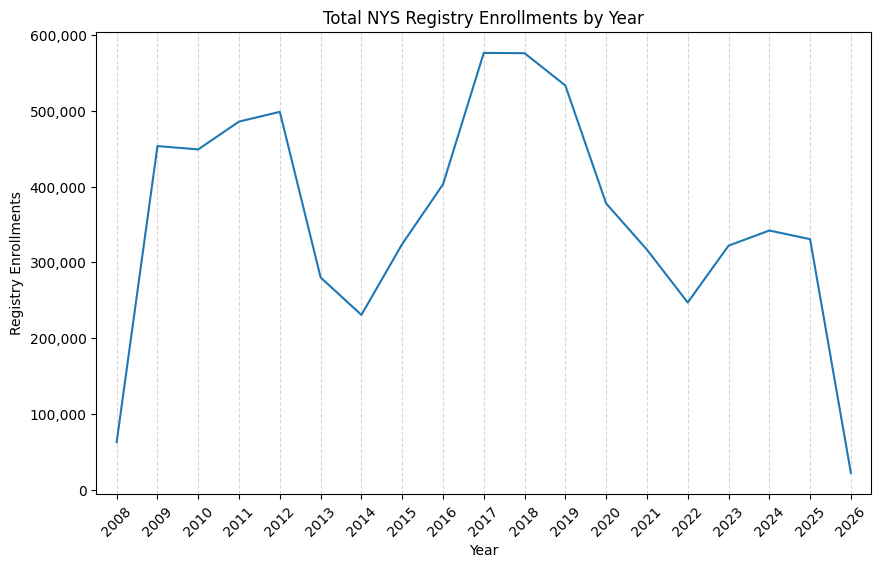

In [17]:
# visualize `yearly_totals_df`

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_totals,
    x="Year",
    y="Registry Enrollments"
)

plt.xlim(2007.5, 2026.5)
plt.xticks(np.arange(2008, 2027, 1))
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.title("Total NYS Registry Enrollments by Year")
plt.xlabel("Year")
# plt.ylabel("Total Enrollments")
plt.show()

In [18]:
## pickle donate_df yearly_df yearly_totals
donate_df.to_pickle("donate_df.pkl")
yearly_df.to_pickle("yearly_df.pkl")
yearly_totals.to_pickle("yearly_totals.pkl")

In [19]:
## pickle donate_df yearly_df yearly_totals

with open("donate_df.pkl", "rb") as f:
    donate_df = pickle.load(f)

with open("yearly_df.pkl", "rb") as f:
    yearly_df = pickle.load(f)

with open("yearly_totals.pkl", "rb") as f:
    yearly_totals = pickle.load(f)

## Visualize 2025 for each zip code? 
No, too many rows (1,011)

In [20]:
# look at 2025
df_2025 = yearly_df[yearly_df['Year'] == 2025].copy()
df_2025

,Zip Code,Year,Registry Enrollments
18,10001,2025,902.0
37,10002,2025,1377.0
56,10003,2025,1561.0
75,10004,2025,93.0
94,10005,2025,303.0
...,...,...,...
18828,14895,2025,217.0
18847,14901,2025,327.0
18866,14903,2025,169.0
18885,14904,2025,401.0


# Zip Code Data
Isolate NYC zip codes?

## zipcode_race_df 
https://www.nyc.gov/assets/planning/download/office/data-maps/nyc-population/census2000/sf1p11.xls 

In [21]:
zipcode_race_df = pd.read_excel('nyc_zip_codes.xls', header=6)

In [22]:
zipcode_race_df = zipcode_race_df.drop(zip_race_df.index[0])
zipcode_race_df = zipcode_race_df.reset_index(drop=True)
zipcode_race_df

NameError: name 'zip_race_df' is not defined

In [ ]:
zipcode_race_df.columns

In [ ]:
# rename columns
zipcode_race_df.rename(columns={'Borough': 'boro',
           'ZIPCODES': 'zip_code', 
           'Unnamed: 2': 'pop_total' ,
           'White': 'white',
           '   Black/ African American': 'black',
           '     American Indian and Alaska Native': 'native',
           '      Asian' : 'asian',
           'Native Hawaiian and Other Pacific Islander':'pacific_islander',
           '  Some Other Race': 'other_race',
            'Unnamed: 9': 'non_hispanic',
           'Unnamed: 10': 'hispanic',
           'Unnamed: 11': 'total_housing_units'}, inplace=True)

## zipcode_df

In [ ]:
zipcode_df = zipcode_race_df[['boro', 'zip_code', 'total_housing_units']]

In [ ]:
zipcode_df

In [ ]:
# pickle zipcode_race_df zipcode_df
zipcode_race_df.to_pickle("zipcode_race_df.pkl")
zipcode_df.to_pickle("zipcode_df.pkl")

In [ ]:
# # unpickle zipcode_race_df zipcode_df

# with open("zipcode_race_df.pkl", "rb") as f:
#     zipcode_race_df = pickle.load(f)

# with open("zipcode_df.pkl", "rb") as f:
#     zipcode_df = pickle.load(f)

# 🔖 use zip code and borough data with original data set